<a href="https://colab.research.google.com/github/Hrshh9482/Log_andThreat_Analyser_/blob/main/nids_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
print(os.listdir("/content"))

['.config', 'KDDTrain+.txt', 'sample_data']


In [8]:
import pandas as pd
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

df = pd.read_csv("/content/KDDTrain+.txt", names = columns)
print(df.shape)
print('-----------------------------------------------------------')
print(df.head())
print('-----------------------------------------------------------')
print(df.info())
print('-----------------------------------------------------------')
print(df["label"].value_counts())
print('-----------------------------------------------------------')

(125973, 43)
-----------------------------------------------------------
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   

In [13]:
import numpy as np
import matplotlib.pyplot as plt
print("missing values: ",df.isnull().sum().sum())
print("duplicated rows: ",df.duplicated().sum())
df["ATTACK_CLASS"] = np.where(df["label"] == 'normal','normal','attack')
print(df['ATTACK_CLASS'].value_counts())

missing values:  0
duplicated rows:  0
ATTACK_CLASS
normal    67343
attack    58630
Name: count, dtype: int64


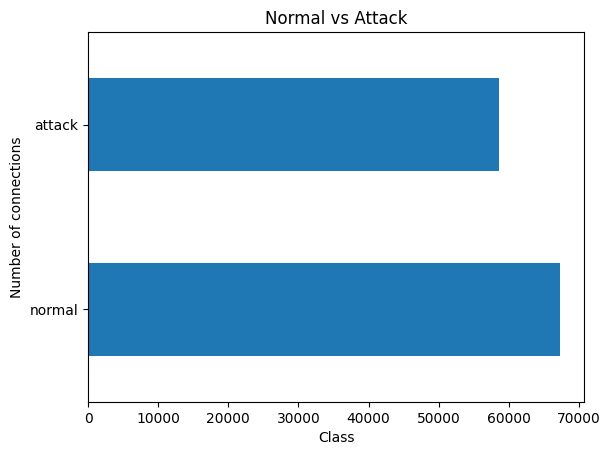

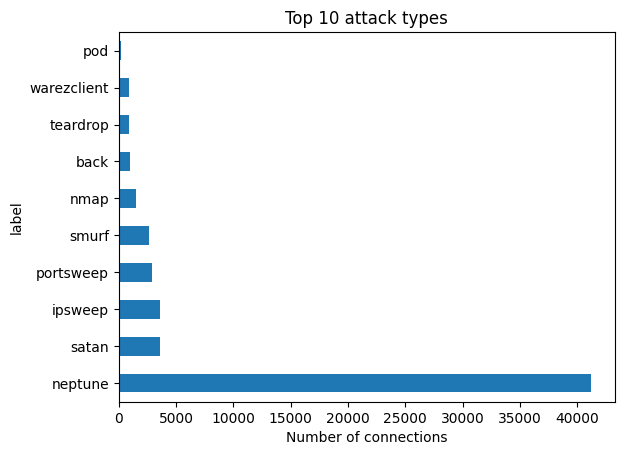

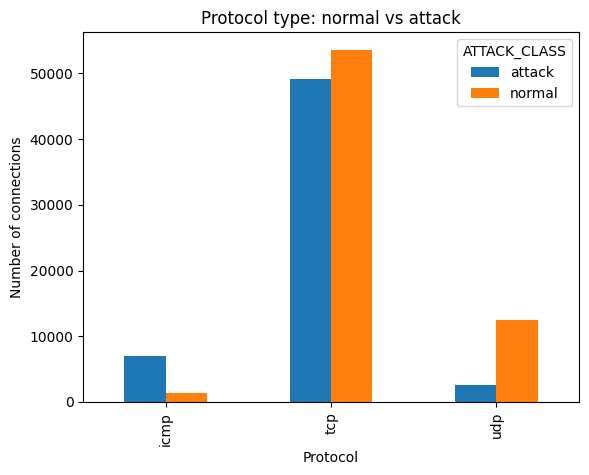

In [17]:
# Chart 1: normal vs attack
df["ATTACK_CLASS"].value_counts().plot(kind="barh")
plt.title("Normal vs Attack")
plt.xlabel("Class")
plt.ylabel("Number of connections")
plt.show()

# Chart 2: top 10 attack types (without normal)
attacks = df[df["label"] != "normal"]
attacks["label"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 attack types")
plt.xlabel("Number of connections")
plt.show()

# Chart 3: protocol type for normal and attack
pd.crosstab(df["protocol_type"], df["ATTACK_CLASS"]).plot(kind="bar")
plt.title("Protocol type: normal vs attack")
plt.xlabel("Protocol")
plt.ylabel("Number of connections")
plt.show()

In [19]:
X = df.drop(columns=["label", "ATTACK_CLASS", "difficulty"])
y = df["ATTACK_CLASS"].map({"normal": 0, "attack": 1})

In [20]:
X = pd.get_dummies(X, columns=["protocol_type", "service", "flag"])

In [21]:
print("X shape:", X.shape)
print("y counts:")
print(y.value_counts())
print("Text columns left:", X.select_dtypes(include="object").shape[1])

X shape: (125973, 122)
y counts:
ATTACK_CLASS
0    67343
1    58630
Name: count, dtype: int64
Text columns left: 0


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Training done")

Train rows: 100778
Test rows: 25195
Training done


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["normal", "attack"]))

Accuracy: 0.9989680492161143
[[13462     7]
 [   19 11707]]
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     13469
      attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

